# Analisis Menggunkan SMOTE 
Fokus pada klasifikasi dengan SMOTE untuk menangani data tidak seimbang.

In [88]:
# Library
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    hinge_loss
)
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

# Auto-install imbalanced-learn if missing
import subprocess, sys
try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE


In [89]:
from pathlib import Path
import pandas as pd
import ast

base = Path.cwd()

candidates = [
    base / 'data' / 'prosses' / 'stemming.csv',
    base / 'analisis' / 'data' / 'prosses' / 'stemming.csv',
]

path = next((p for p in candidates if p.exists()), None)

if path is None:
    print("CWD:", base)
    print("Tried:")
    for p in candidates:
        print("-", p)
    raise FileNotFoundError("File stemming.csv tidak ditemukan.")

df = pd.read_csv(path, sep=';')
df['stemming'] = df['stemming'].apply(ast.literal_eval)

print(f"Path aktif: {path}")
print(f"Total data: {len(df)}")
df.head()


Path aktif: d:\PROYEK TUGAS AKHIR\APP TA\analisis\data\prosses\stemming.csv
Total data: 2175


,stemming,label
0,"[hotel, mudah, temu, jalan, malioboro, karyawa...",Negatif
1,"[lokasi, atas, lokasi, hotel, banyak, toko, to...",Positif
2,"[pengalaman, menginap, tidak, senang, menginap...",Negatif
3,"[lokasi, mudah, temu, makan, lengkap, variasi,...",Positif
4,"[anak, nikmat, menginap, hotel, kolam, renang,...",Positif


In [90]:
# Pastikan kolom label tersedia
if 'encoded' not in df.columns:
    df['encoded'] = df['label'].map({'Negatif': 0, 'Positif': 1})

# Parsing kolom stemming (list token) dari string

def safe_eval(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

df['stemming'] = df['stemming'].apply(safe_eval)

# Filter data valid
mask_valid = df['stemming'].apply(lambda v: isinstance(v, list) and len(v) > 0)
df = df[mask_valid].copy()

X = df['stemming']
y = df['encoded'].astype(int)
print('Distribusi label awal:', np.bincount(y))


Distribusi label awal: [ 185 1990]


In [91]:
df

,stemming,label,encoded
0,"[hotel, mudah, temu, jalan, malioboro, karyawa...",Negatif,0
1,"[lokasi, atas, lokasi, hotel, banyak, toko, to...",Positif,1
2,"[pengalaman, menginap, tidak, senang, menginap...",Negatif,0
3,"[lokasi, mudah, temu, makan, lengkap, variasi,...",Positif,1
4,"[anak, nikmat, menginap, hotel, kolam, renang,...",Positif,1
...,...,...,...
2170,"[kerja, bagus, nyaman]",Positif,1
2171,"[bagus, nyaman]",Positif,1
2172,"[karyawan, ramah, ramah]",Positif,1
2173,"[bagus, tarik]",Positif,1


In [92]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Distribusi label train:', np.bincount(y_train))
print('Distribusi label test :', np.bincount(y_test))


Distribusi label train: [ 148 1592]
Distribusi label test : [ 37 398]


TF-IDF

In [93]:
# TF-IDF

def identity_tokenizer(text):
    return text

def identity_preprocessor(text):
    return text

tfidf = TfidfVectorizer(
    tokenizer=identity_tokenizer,
    preprocessor=identity_preprocessor,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=2,
    sublinear_tf=True,
    norm='l2'
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)



In [94]:
tfidf.get_feature_names_out()[:200]

array(['abai', 'acara', 'acara karyawan', 'ada', 'agam', 'agam makan',
       'ah', 'air', 'air kamar', 'air kamar mandi', 'air mineral',
       'air mineral lorong', 'air minum', 'air minum ambil', 'air panas',
       'air panas fungsi', 'air panas lancar', 'air pancur', 'air toilet',
       'air ukur', 'air ukur ml', 'air wudhu', 'ajak', 'ajak anak',
       'akal', 'akibat', 'akomodasi', 'akses', 'akses dekat',
       'akses hotel', 'akses jalan', 'akses malioboro', 'akses mana',
       'akses mana dekat', 'akses mana mudah', 'akses masuk',
       'akses masuk kurang', 'akses mobil', 'akses mudah',
       'akses mudah dekat', 'akses mudah layan', 'akses mudah nyaman',
       'akses parkir', 'akses pintu', 'akses ruang', 'akses ruang tunggu',
       'akses stasiun', 'akses sulit', 'akses tempat',
       'akses tempat parkir', 'alamat', 'alami', 'alangkah',
       'alangkah baik', 'alas', 'alat', 'alfamart', 'alfamart tidak',
       'alhamdulilah', 'alun', 'aman', 'aman bantu', 'aman h

SMOTE

In [95]:
# SMOTE pada data train
smote = SMOTE(random_state=42)

try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)
except Exception as e:
    print('SMOTE gagal pada sparse matrix, fallback ke dense. Error:', e)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_vec.toarray(), y_train)
    X_test_vec = X_test_vec.toarray()

print('Distribusi label setelah SMOTE:', np.bincount(y_train_smote))


Distribusi label setelah SMOTE: [1592 1592]


In [96]:
print(np.bincount(y_train))         # sebelum SMOTE
print(np.bincount(y_train_smote))   # sesudah SMOTE


[ 148 1592]
[1592 1592]


NAIVE BAYES + SMOTE

Best Parameter: {'alpha': 0.01}
Best CV Score : 0.9836652040478733
TRAINING EVALUATION (NB - SMOTE)
Accuracy (Train): 0.9879310344827587
Classification Report (Train):
              precision    recall  f1-score   support

     Negatif       0.88      1.00      0.93       148
     Positif       1.00      0.99      0.99      1592

    accuracy                           0.99      1740
   macro avg       0.94      0.99      0.96      1740
weighted avg       0.99      0.99      0.99      1740



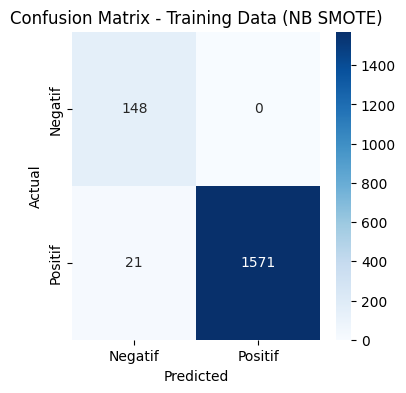

TESTING EVALUATION (NB - SMOTE)
Accuracy      : 0.9379
Precision     : 0.9437
Recall        : 0.9379
F1-Score      : 0.9403
Log Loss      : 0.1765
Balanced Acc  : 0.8435
Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.61      0.73      0.67        37
     Positif       0.97      0.96      0.97       398

    accuracy                           0.94       435
   macro avg       0.79      0.84      0.82       435
weighted avg       0.94      0.94      0.94       435



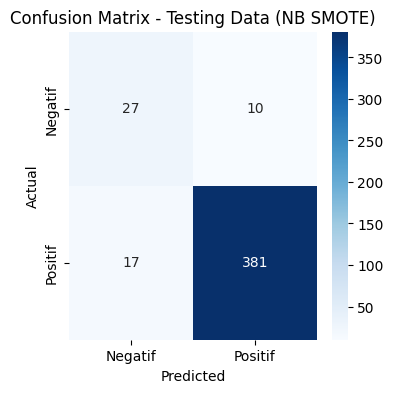

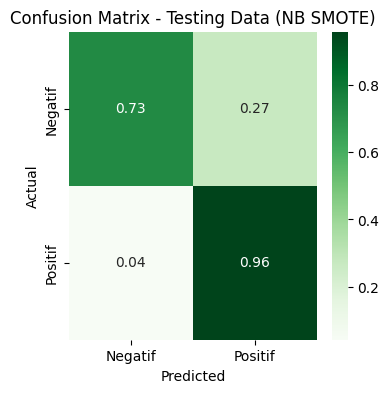

In [97]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, log_loss,
    balanced_accuracy_score
)

# ===== CROSS VALIDATION =====
cv_nb = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ===== PARAMETER GRID =====
param_grid_nb = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 10, 1000]
}

# ===== GRID SEARCH =====
grid_nb = GridSearchCV(
    estimator=ComplementNB(),
    param_grid=param_grid_nb,
    cv=cv_nb,
    scoring='f1_macro',
    n_jobs=1
)

grid_nb.fit(X_train_smote, y_train_smote)

print("Best Parameter:", grid_nb.best_params_)
print("Best CV Score :", grid_nb.best_score_)

# ===== MODEL TERBAIK =====
nb = grid_nb.best_estimator_

# =========================
# TRAINING EVALUATION
# =========================
print("TRAINING EVALUATION (NB - SMOTE)")
nb_train_pred = nb.predict(X_train_vec)

train_acc = accuracy_score(y_train, nb_train_pred)
print("Accuracy (Train):", train_acc)
print("Classification Report (Train):")
print(classification_report(y_train, nb_train_pred, target_names=["Negatif", "Positif"]))

cm_train = confusion_matrix(y_train, nb_train_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Data (NB SMOTE)")
plt.show()

# =========================
# TESTING EVALUATION
# =========================
print("TESTING EVALUATION (NB - SMOTE)")
nb_pred = nb.predict(X_test_vec)
y_proba = nb.predict_proba(X_test_vec)

acc = accuracy_score(y_test, nb_pred)
prec = precision_score(y_test, nb_pred, average='weighted')
rec = recall_score(y_test, nb_pred, average='weighted')
f1 = f1_score(y_test, nb_pred, average='weighted')
loss = log_loss(y_test, y_proba)
bal_acc = balanced_accuracy_score(y_test, nb_pred)

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"Log Loss      : {loss:.4f}")
print(f"Balanced Acc  : {bal_acc:.4f}")

print("Classification Report (Test):")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Negatif", "Positif"]
))

cm_test = confusion_matrix(y_test, nb_pred)
cm_test_norm = confusion_matrix(y_test, nb_pred, normalize='true')

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (NB SMOTE)")
plt.show()

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_test_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (NB SMOTE)")
plt.show()


SUPPORT VECTOR MACHINE (SVM) + SMOTE

Best Parameter: {'C': 2}
Best CV Score : 0.9877496392982387
TRAINING EVALUATION (SVM - SMOTE)
Accuracy (Train): 1.0
Hinge Loss (Train): 0.02910587992556724
Classification Report (Train):
              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00       148
     Positif       1.00      1.00      1.00      1592

    accuracy                           1.00      1740
   macro avg       1.00      1.00      1.00      1740
weighted avg       1.00      1.00      1.00      1740



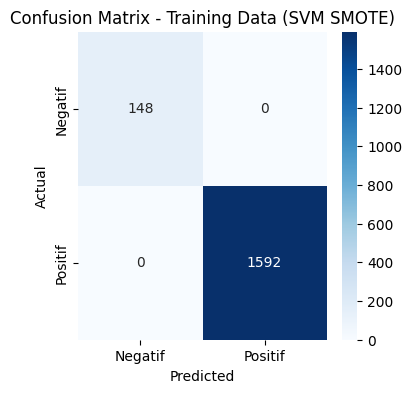

TESTING EVALUATION (SVM - SMOTE)
Accuracy      : 0.9540
Precision     : 0.9514
Recall        : 0.9540
F1-Score      : 0.9522
Hinge Loss    : 0.1559
Balanced Acc  : 0.8155
Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.77      0.65      0.71        37
     Positif       0.97      0.98      0.98       398

    accuracy                           0.95       435
   macro avg       0.87      0.82      0.84       435
weighted avg       0.95      0.95      0.95       435



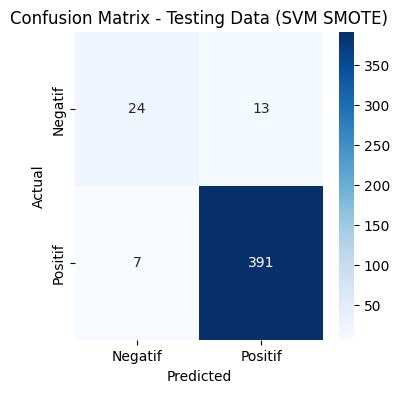

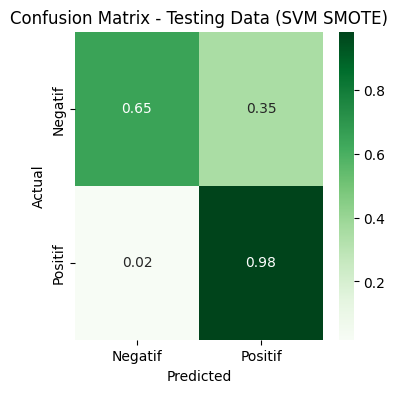

In [98]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, hinge_loss,
    balanced_accuracy_score
)

# ===== PARAMETER GRID =====
param_grid_svm = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2]
}

# ===== BASE MODEL =====
base_svm = LinearSVC(
    class_weight="balanced",
    max_iter=15000,
    random_state=42,
    dual=False
)

# ===== CROSS VALIDATION =====
cv_svm = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ===== GRID SEARCH =====
grid_svm = GridSearchCV(
    estimator=base_svm,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv_svm,
    n_jobs=1
)

grid_svm.fit(X_train_smote, y_train_smote)

print("Best Parameter:", grid_svm.best_params_)
print("Best CV Score :", grid_svm.best_score_)

# ===== MODEL TERBAIK =====
svm = grid_svm.best_estimator_

# =========================
# TRAINING EVALUATION
# =========================
print("TRAINING EVALUATION (SVM - SMOTE)")
svm_train_pred = svm.predict(X_train_vec)
y_score_train = svm.decision_function(X_train_vec)

train_acc = accuracy_score(y_train, svm_train_pred)
train_loss = hinge_loss(y_train, y_score_train)

print("Accuracy (Train):", train_acc)
print("Hinge Loss (Train):", train_loss)
print("Classification Report (Train):")
print(classification_report(y_train, svm_train_pred, target_names=["Negatif", "Positif"]))

cm_train = confusion_matrix(y_train, svm_train_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Data (SVM SMOTE)")
plt.show()

# =========================
# TESTING EVALUATION
# =========================
print("TESTING EVALUATION (SVM - SMOTE)")
svm_pred = svm.predict(X_test_vec)
y_score = svm.decision_function(X_test_vec)

acc = accuracy_score(y_test, svm_pred)
prec = precision_score(y_test, svm_pred, average='weighted')
rec = recall_score(y_test, svm_pred, average='weighted')
f1 = f1_score(y_test, svm_pred, average='weighted')
loss = hinge_loss(y_test, y_score)
bal_acc = balanced_accuracy_score(y_test, svm_pred)

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"Hinge Loss    : {loss:.4f}")
print(f"Balanced Acc  : {bal_acc:.4f}")

print("Classification Report (Test):")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Negatif", "Positif"]
))

cm_test = confusion_matrix(y_test, svm_pred)
cm_test_norm = confusion_matrix(y_test, svm_pred, normalize='true')

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM SMOTE)")
plt.show()

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_test_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM SMOTE)")
plt.show()


DOWNLOAD MODEL SMOTE

In [99]:
import json
import joblib
from pathlib import Path

project_root = Path.cwd()
if not (project_root / 'analisis').exists() and project_root.name == 'analisis':
    project_root = project_root.parent

MODEL_DIR = project_root / 'analisis' / 'model_machine_smote'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(nb, MODEL_DIR / 'naive_bayes_model_smote.pkl')
joblib.dump(svm, MODEL_DIR / 'SVM_model_smote.pkl')
joblib.dump(tfidf, MODEL_DIR / 'vectorizer_smote.pkl')

metrics_smote = {
    "nb": {
        "best_params": grid_nb.best_params_,
        "accuracy": float(accuracy_score(y_test, nb_pred)),
        "precision_weighted": float(precision_score(y_test, nb_pred, average="weighted")),
        "recall_weighted": float(recall_score(y_test, nb_pred, average="weighted")),
        "f1_weighted": float(f1_score(y_test, nb_pred, average="weighted")),
        "f1_macro": float(f1_score(y_test, nb_pred, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, nb_pred)),
        "log_loss": float(log_loss(y_test, y_proba))
    },
    "svm": {
        "best_params": grid_svm.best_params_,
        "accuracy": float(accuracy_score(y_test, svm_pred)),
        "precision_weighted": float(precision_score(y_test, svm_pred, average="weighted")),
        "recall_weighted": float(recall_score(y_test, svm_pred, average="weighted")),
        "f1_weighted": float(f1_score(y_test, svm_pred, average="weighted")),
        "f1_macro": float(f1_score(y_test, svm_pred, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, svm_pred)),
        "hinge_loss": float(hinge_loss(y_test, y_score))
    },
    "tfidf_vocab_size": int(len(tfidf.get_feature_names_out())),
    "smote": True
}

with open(MODEL_DIR / 'metrics_nb_svm_smote.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_smote, f, indent=2)

print(f"Model dan metrics SMOTE berhasil disimpan di: {MODEL_DIR}")



Model dan metrics SMOTE berhasil disimpan di: d:\PROYEK TUGAS AKHIR\APP TA\analisis\model_machine_smote


In [ ]:
# # Kode Testing Hasil Smote
# # ===== UJI TEKS SATUAN (TF-IDF + MODEL SAJA) =====
# text = "Saya sangat kecewa dengan penananganan lost and foundnya. Saya ada tertinggal barang di hotel, dan saya kontak kepada petugas terkait supaya tolong dikeep sementara karena akan ada rekan saya yg akan mengambil barang saya yg tertinggal tsb. Saya sudah ingatkan berkali-kali agar dikeep dengan baik. Harusnya saat didatangi oleh rekan saya normalnya barang sudah dikeep dengan aman dan tersedia dong. Bahkan dokumentasi barangnya yg tertinggal seperti apa sudah diketahui oleh pihak hotel. Namun anehnya saat didatangi oleh rekan saya, barang statusnya malah masih dicari, rekan saya kabarnya sudah cukup lama menunggu petugas mencari dan harus segera meninggalkan hotel karena keburu jadwal keberangkatan kereta"

# X_one = tfidf.transform([text])

# pred_nb = nb.predict(X_one)[0]
# pred_svm = svm.predict(X_one)[0]

# label_map = {0: "Negatif", 1: "Positif"}

# print("Teks :", text)
# print("NB  :", label_map.get(int(pred_nb), pred_nb))
# print("SVM :", label_map.get(int(pred_svm), pred_svm))
